In [1]:
import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import imageio.v3 as iio
import os
from PIL import Image
import imagehash


# Data loading and Processing

In [2]:
Image_size = 96
Batch = 32
Random_seed = 42

train_Bi_raw = tf.keras.utils.image_dataset_from_directory(
    "Training_Bi/",
    validation_split=0.15,
    subset="training",
    seed=Random_seed,
    image_size=(Image_size, Image_size),
    batch_size=None
)

val_Bi_raw = tf.keras.utils.image_dataset_from_directory(
    "Training_Bi/",
    validation_split=0.15,
    subset="validation",
        seed=Random_seed,
        image_size=(Image_size, Image_size),
        batch_size=None
)

test_Bi_raw = tf.keras.utils.image_dataset_from_directory(
    "Test/",
    image_size=(Image_size, Image_size),
    batch_size=None,
    shuffle=False
)



Found 39375 files belonging to 2 classes.
Using 33469 files for training.
Found 39375 files belonging to 2 classes.
Using 5906 files for validation.
Found 8617 files belonging to 2 classes.


In [3]:
def focal_loss(gamma, alpha):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss


def augment(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform((), 0, 4, dtype=tf.int32))
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    image = tf.image.random_hue(image, max_delta=0.05)
    
    # Haze - fixed with tf.cond
    haze_intensity = tf.random.uniform((), 0.05, 0.25)
    haze = tf.ones_like(image) * 0.7
    image = tf.cond(
        tf.random.uniform(()) > 0.5,
        lambda: image * (1 - haze_intensity) + haze * haze_intensity,
        lambda: image
    )

    # Blur - fixed with tf.cond
    def apply_blur(img):
        img = tf.expand_dims(img, 0)
        img = tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')
        return tf.squeeze(img, 0)

    image = tf.cond(
        tf.random.uniform(()) > 0.6,
        lambda: apply_blur(image),
        lambda: image
    )

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def compute_class_weights(ds):
    labels = np.array([y.numpy() for _, y in ds])
    counts = np.bincount(labels)
    total = len(labels)
    weights = {i: total / (len(counts) * c) for i, c in enumerate(counts)}
    print(f"Class weights: {weights}")
    return weights

In [4]:
class_weights = compute_class_weights(train_Bi_raw)

train_ds = (
    train_Bi_raw
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    val_Bi_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    test_Bi_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

Class weights: {0: 0.787542943197327, 1: 1.3694353518821605}


In [5]:
model = keras.models.Sequential([
    
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
    
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
   
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.3),
   
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.40),
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
    ]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        'best_fire_model.keras',
        monitor='val_recall',
        save_best_only=True,
    )
]

history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    class_weight=None,
    callbacks=callbacks
)

Epoch 1/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8593 - loss: 0.0371 - precision: 0.9409 - recall: 0.6557 - val_accuracy: 0.9414 - val_loss: 0.0226 - val_precision: 0.9776 - val_recall: 0.8577 - learning_rate: 1.0000e-04
Epoch 2/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9299 - loss: 0.0237 - precision: 0.9560 - recall: 0.8471 - val_accuracy: 0.9175 - val_loss: 0.0272 - val_precision: 0.8917 - val_recall: 0.8788 - learning_rate: 1.0000e-04
Epoch 3/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9346 - loss: 0.0222 - precision: 0.9652 - recall: 0.8515 - val_accuracy: 0.9396 - val_loss: 0.0189 - val_precision: 0.9714 - val_recall: 0.8582 - learning_rate: 1.0000e-04
Epoch 4/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9356 - loss: 0.0213 - precision: 0.9663 - recall: 0.8533 - val_accuracy: 0.9396 - val_loss: 0.0177 - val_precision: 0.9719 - val_recall: 0.8577 - learning_rate: 1.0000e-04
Epoch 5/30
1046/1046 ━━━━━━━━━━━

In [6]:
loss, acc, recall, precision = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test Precision: {precision:.4f}")

# Get probabilities
y_pred_prob = model.predict(test_ds)

# 2. Confusion matrix
true_labels = np.concatenate([y.numpy() for _, y in test_ds])

pred_classes = (y_pred_prob > 0.35).astype(int).flatten()
cm = confusion_matrix(true_labels, pred_classes)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(true_labels, pred_classes, target_names=['No_Fire', 'Fire']))

270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7012 - loss: 0.0713 - precision: 0.6866 - recall: 0.4784
Test Loss: 0.0713
Test Accuracy: 0.7012
Test Recall: 0.4784
Test Precision: 0.6866
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Confusion Matrix:
[[3359 1778]
 [ 591 2889]]

Classification Report:
              precision    recall  f1-score   support

     No_Fire       0.85      0.65      0.74      5137
        Fire       0.62      0.83      0.71      3480

    accuracy                           0.73      8617
   macro avg       0.73      0.74      0.72      8617
weighted avg       0.76      0.73      0.73      8617



In [7]:
for t in np.arange(0.25, 0.70, 0.05):
    pred_classes = (y_pred_prob > t).astype(int).flatten()
    print(f"Threshold {t:.2f}:", classification_report(true_labels, pred_classes, target_names=['No_Fire', 'Fire'], output_dict=True)['macro avg']['f1-score'])

Threshold 0.25: 0.456597538163275
Threshold 0.30: 0.6232081450539082
Threshold 0.35: 0.7242580075972499
Threshold 0.40: 0.736578622956049
Threshold 0.45: 0.7070653494256129
Threshold 0.50: 0.6683180427083155
Threshold 0.55: 0.6181360526818916
Threshold 0.60: 0.5781602337570946
Threshold 0.65: 0.5437825627926303


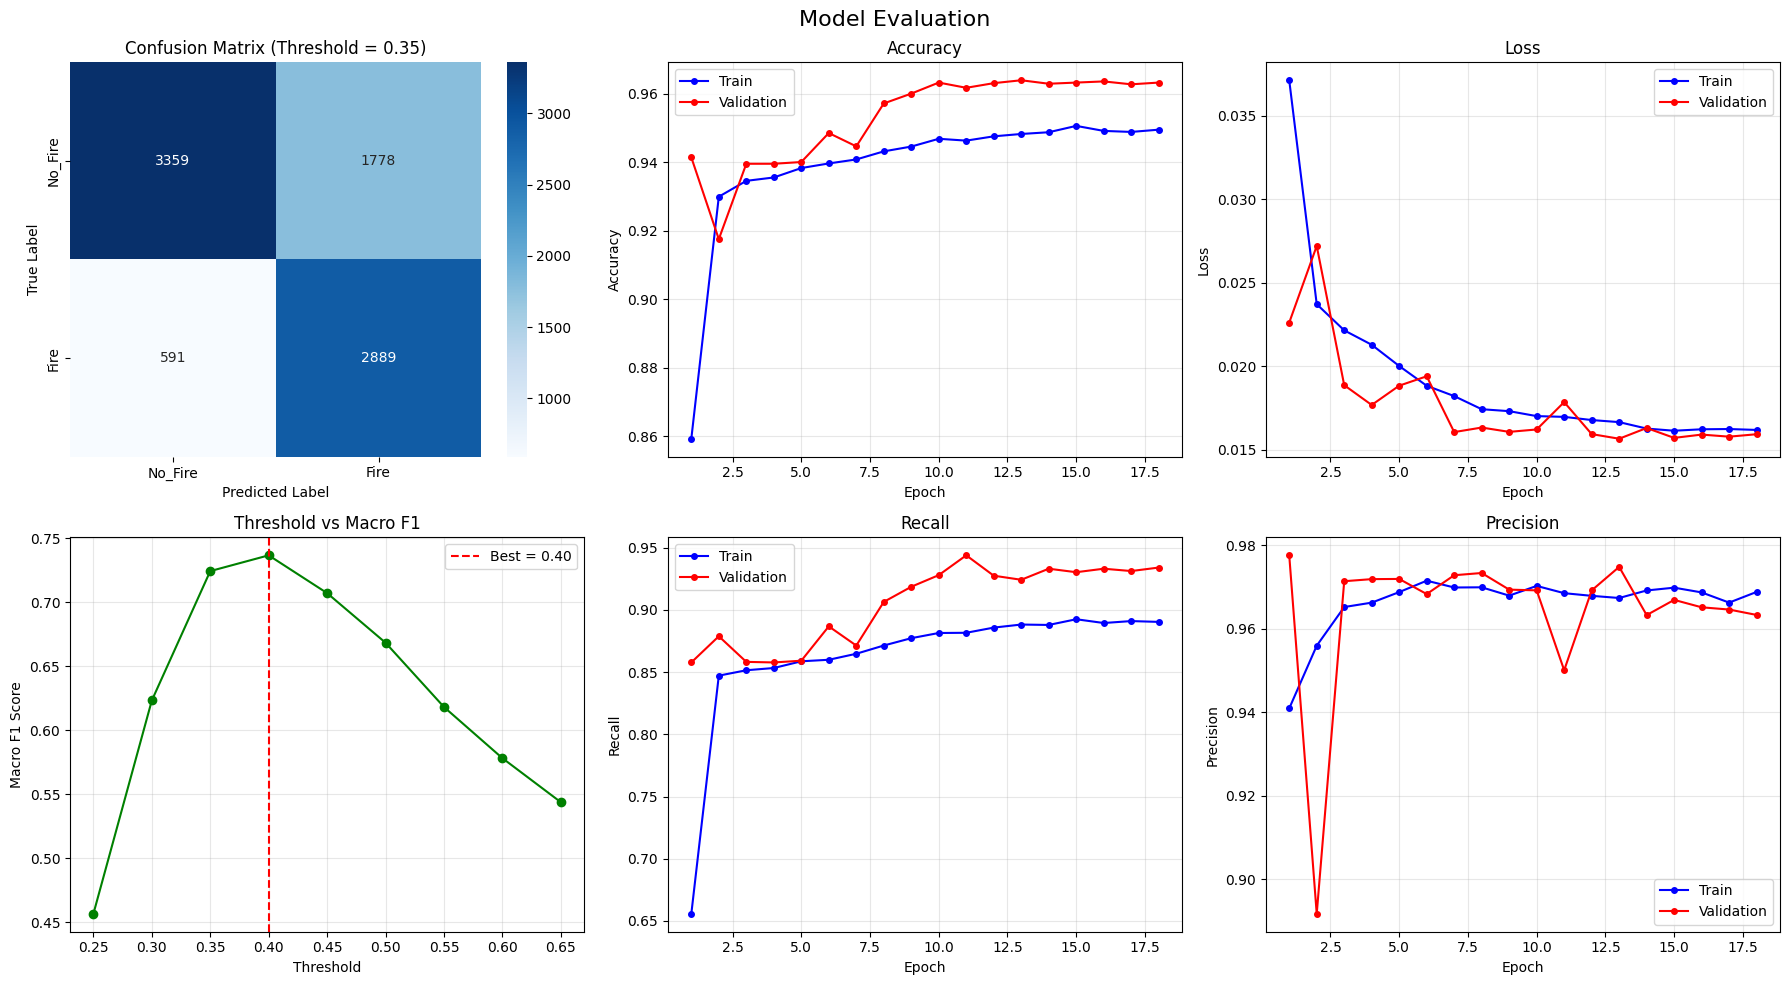

In [8]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Evaluation', fontsize=16)

# --- Confusion Matrix ---
ax = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No_Fire', 'Fire'],
            yticklabels=['No_Fire', 'Fire'], ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix (Threshold = 0.35)')

# --- Training Plateau Plots ---
metrics = [
    ('accuracy',  'val_accuracy',  'Accuracy'),
    ('loss',      'val_loss',      'Loss'),
    ('recall',    'val_recall',    'Recall'),
    ('precision', 'val_precision', 'Precision'),
]
positions = [(0,1), (0,2), (1,1), (1,2)]

for (r, c), (train_key, val_key, title) in zip(positions, metrics):
    ax = axes[r, c]
    epochs = range(1, len(history.history[train_key]) + 1)
    ax.plot(epochs, history.history[train_key], 'b-o', markersize=4, label='Train')
    ax.plot(epochs, history.history[val_key],   'r-o', markersize=4, label='Validation')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

# --- Threshold vs F1 ---
ax = axes[1, 0]
thresholds = np.arange(0.25, 0.70, 0.05)
f1_scores = [
    classification_report(true_labels, (y_pred_prob > t).astype(int).flatten(),
                          output_dict=True)['macro avg']['f1-score']
    for t in thresholds
]
ax.plot(thresholds, f1_scores, 'g-o', markersize=6)
ax.axvline(thresholds[np.argmax(f1_scores)], color='red', linestyle='--',
           label=f'Best = {thresholds[np.argmax(f1_scores)]:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Macro F1 Score')
ax.set_title('Threshold vs Macro F1')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()